In [77]:
from numpy.ma.core import arange
from ucimlrepo import fetch_ucirepo
concrete_dataset = fetch_ucirepo(id=165)

In [78]:
concrete_dataset.keys()

dict_keys(['data', 'metadata', 'variables'])

In [79]:
concrete_dataset['variables']

,name,role,type,demographic,description,units,missing_values
0,Cement,Feature,Continuous,None,None,kg/m^3,no
1,Blast Furnace Slag,Feature,Integer,None,None,kg/m^3,no
2,Fly Ash,Feature,Continuous,None,None,kg/m^3,no
3,Water,Feature,Continuous,None,None,kg/m^3,no
4,Superplasticizer,Feature,Continuous,None,None,kg/m^3,no
5,Coarse Aggregate,Feature,Continuous,None,None,kg/m^3,no
6,Fine Aggregate,Feature,Continuous,None,None,kg/m^3,no
7,Age,Feature,Integer,None,None,day,no
8,Concrete compressive strength,Target,Continuous,None,None,MPa,no


In [80]:
concrete_dataset['data']

{'ids': None,
 'features':       Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
 0      540.0                 0.0      0.0  162.0               2.5   
 1      540.0                 0.0      0.0  162.0               2.5   
 2      332.5               142.5      0.0  228.0               0.0   
 3      332.5               142.5      0.0  228.0               0.0   
 4      198.6               132.4      0.0  192.0               0.0   
 ...      ...                 ...      ...    ...               ...   
 1025   276.4               116.0     90.3  179.6               8.9   
 1026   322.2                 0.0    115.6  196.0              10.4   
 1027   148.5               139.4    108.6  192.7               6.1   
 1028   159.1               186.7      0.0  175.6              11.3   
 1029   260.9               100.5     78.3  200.6               8.6   
 
       Coarse Aggregate  Fine Aggregate  Age  
 0               1040.0           676.0   28  
 1               1055.0   

In [81]:
X = concrete_dataset.data.features
y = concrete_dataset.data.targets

In [82]:
X.sample(n=5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
28,427.5,47.5,0.0,228.0,0.0,932.0,594.0,28
659,108.3,162.4,0.0,203.5,0.0,938.2,849.0,90
212,230.0,0.0,118.3,195.5,4.6,1029.4,758.6,56
533,289.0,0.0,0.0,192.0,0.0,913.2,895.3,3
565,295.8,0.0,0.0,185.7,0.0,1091.4,769.3,7


In [83]:
y.sample(n=5)

,Concrete compressive strength
275,29.93
243,40.86
366,52.20
338,58.61
419,16.88


In [91]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

# Using Linear Regression

In [92]:
from sklearn.linear_model import LinearRegression
import numpy as np
lr = LinearRegression().fit(X_train, y_train)
print(f"Training set accuracy is: {lr.score(X_train, y_train)}")
print(f"Testing set accuracy is: {lr.score(X_test, y_test)}")
print(f"The coefficients are: {np.count_nonzero(lr.coef_)}")

Training set accuracy is: 0.6105238047649741
Testing set accuracy is: 0.6275531792314848
The coefficients are: 8


# Using the Ridge regression

In [93]:
from sklearn.linear_model import Ridge
rr = Ridge().fit(X_train, y_train)
print(f"Training set accuracy is: {rr.score(X_train, y_train)}")
print(f"Testing set accuracy is: {rr.score(X_test, y_test)}")
print(f"The coefficients are: {np.count_nonzero(rr.coef_)}")

Training set accuracy is: 0.6105238047320662
Testing set accuracy is: 0.6275533521253213
The coefficients are: 8


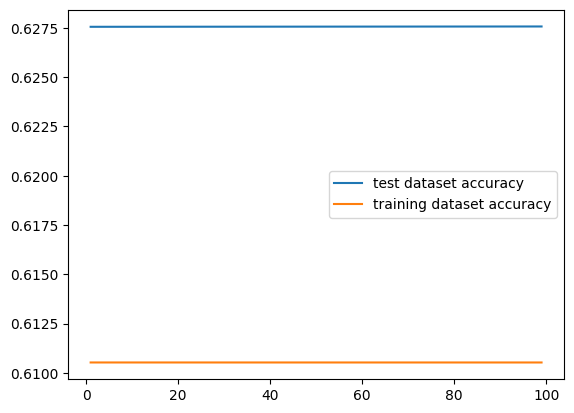

In [94]:
import matplotlib.pyplot as plt
test_accuracies = []
train_accuracies = []
alpha_values = np.arange(1, 100, 1)

for n in alpha_values:
    rr = Ridge(alpha=n).fit(X_train, y_train)
    test_accuracies.append(rr.score(X_test, y_test))
    train_accuracies.append(rr.score(X_train, y_train))

plt.plot(alpha_values, test_accuracies, label='test dataset accuracy')
plt.plot(alpha_values, train_accuracies, label='training dataset accuracy')
plt.legend()
plt.show()

# Using Lasso Regression

In [100]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error
lsr = Lasso(alpha=0.1, max_iter=5000).fit(X_train, y_train)
y_pred = lsr.predict(X_test)
print(f"R2 score is: {r2_score(y_test, y_pred)}")
print(f"Mean squared error: {mean_squared_error(y_test, y_pred)}")

R2 score is: 0.6275755743383957
Mean squared error: 95.9651693895091


In [101]:
from sklearn.linear_model import LassoCV
lassoCv = LassoCV(alphas=np.linspace(0.001, 1, 100), cv=5, max_iter=5000)
lassoCv.fit(X_train, y_train)
print(f"The best alpha is: {lassoCv.alpha_}")
print(f"R2 value is: {lassoCv.score(X_test, y_test)}")

The best alpha is: 0.5055454545454545
R2 value is: 0.6276255693791548


C:\Users\Admin\Documents\machine learing and big data repo\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
